In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Load Dataset
# Note: Ensure 'EastWestAirlines.xlsx' is in your working directory
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')
df = df.drop(columns=['ID#']) # Drop unique ID as per instructions [cite: 25]

In [3]:
# --- 2. Data Preprocessing [cite: 6, 7] ---
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

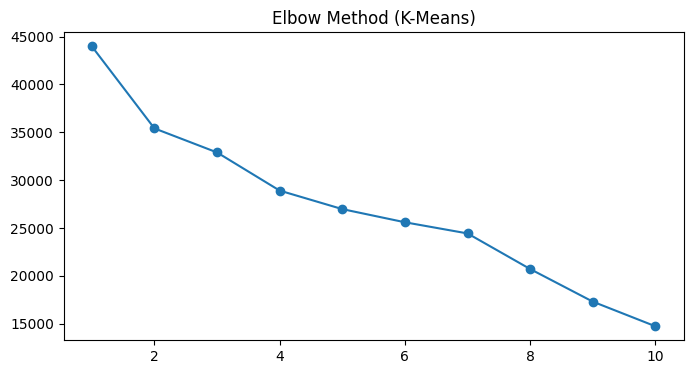

In [4]:
# --- 3. K-Means Clustering  ---
# Elbow Method to find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (K-Means)')
plt.show()

# Applying K-Means (Assuming K=4 based on elbow)
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Labels'] = kmeans.fit_predict(df_scaled)

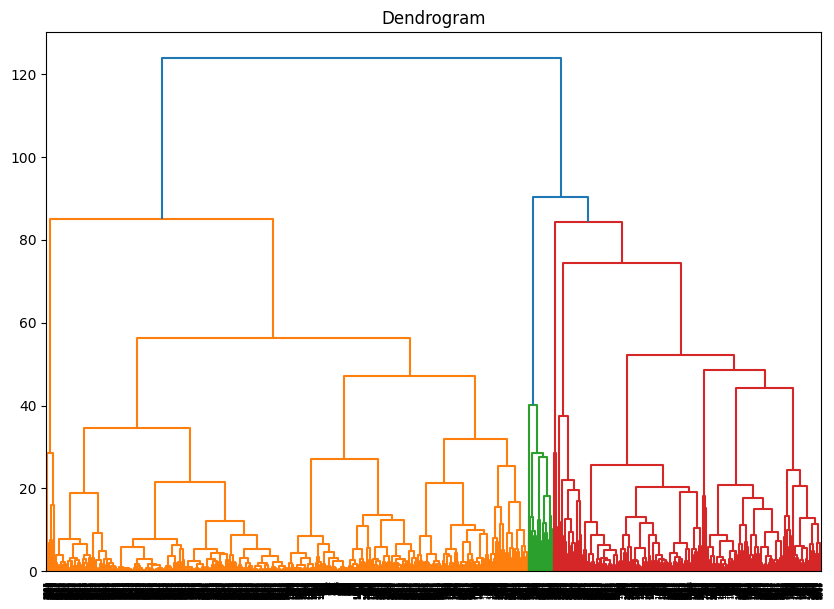

In [9]:
# --- 4. Hierarchical Clustering  ---
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))
plt.title('Dendrogram')
plt.show()

# Applying Agglomerative Clustering
h_clusters = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['Hierarchical_Labels'] = h_clusters.fit_predict(df_scaled)

In [10]:
# --- 5. DBSCAN Clustering  ---
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan.fit_predict(df_scaled)

In [11]:
# --- 6. Evaluation [cite: 20, 21] ---
print(f"K-Means Silhouette Score: {silhouette_score(df_scaled, df['KMeans_Labels']):.3f}")
print(f"Hierarchical Silhouette Score: {silhouette_score(df_scaled, df['Hierarchical_Labels']):.3f}")

K-Means Silhouette Score: 0.191
Hierarchical Silhouette Score: 0.308
